# Gün 14 Demo - Örnekleme Parametrelerinin Dağılıma Etkisi

Raporda temperature, top-k, top-p ve tekrar cezalarının ne yaptığını yazdım. Burada
hepsini hesaplayarak gösteriyorum.

**Neden gerçek bir model çağırmıyorum?** Çünkü bu parametreler modelin içinde değil,
modelin **çıktısının üstünde** çalışıyor. Model bir olasılık dağılımı üretiyor, bu
parametreler o dağılımı değiştiriyor, sonra seçim yapılıyor. Yani parametreleri
anlamak için modele ihtiyacım yok; elimde bir dağılım olması yeterli.

Gerçek modelle çalışsaydım aradaki her şey kara kutu olurdu ve sadece çıktının
değiştiğini görürdüm, **neden** değiştiğini göremezdim. Burada dağılımın kendisine
bakabiliyorum.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("numpy:", np.__version__)

numpy: 2.5.1


## 1. Adım - Bir dağılım kuruyorum

"Türkiye'nin başkenti" girdisinden sonra modelin üretebileceği tokenları ve onlara
verdiği ham skorları (logit) elle yazıyorum.

Model bu aşamada tek bir kelime seçmiyor; sözlükteki **bütün** tokenlar için bir skor
üretiyor. Bu skorlar softmax'tan geçirilince olasılığa dönüşüyor.

Softmax şunu yapıyor: her skorun üssünü al, hepsinin toplamına böl. Üs alma işlemi
büyük skorları orantısız şekilde öne çıkarıyor, bölme işlemi de toplamı 1'e
sabitliyor.

In [2]:
kelimeler = ["Ankara", "İstanbul", "İzmir", "Bursa", "Antalya",
             "şehri", "burada", "bir", "ve", "çok"]

# modelin ham çıktısı: logitler (olasılık değil, skor)
logitler = np.array([7.0, 4.5, 3.0, 2.5, 2.2, 2.0, 1.5, 1.0, 0.5, 0.2])


def softmax(x):
    x = x - np.max(x)            # taşma olmasın diye en büyüğü çıkarıyorum
    us = np.exp(x)
    return us / us.sum()


olasiliklar = softmax(logitler)

print(f"{'token':12} {'logit':>7} {'olasılık':>10}")
print("-" * 31)
for k, lg, p in zip(kelimeler, logitler, olasiliklar):
    print(f"{k:12} {lg:>7.1f} {p:>10.4f}")
print("-" * 31)
print(f"{'TOPLAM':12} {'':>7} {olasiliklar.sum():>10.4f}")

token          logit   olasılık
-------------------------------
Ankara           7.0     0.8805
İstanbul         4.5     0.0723
İzmir            3.0     0.0161
Bursa            2.5     0.0098
Antalya          2.2     0.0072
şehri            2.0     0.0059
burada           1.5     0.0036
bir              1.0     0.0022
ve               0.5     0.0013
çok              0.2     0.0010
-------------------------------
TOPLAM                   1.0000


Model "Ankara"dan oldukça emin. Ama diğer tokenların olasılığı sıfır değil; işte
örnekleme parametreleri bu küçük olasılıklarla ne yapılacağını belirliyor.

## 2. Adım - Temperature

Sıcaklık, softmax'tan **önce** logitleri kendisine bölüyor:

```
olasılık = softmax(logit / T)
```

Neden bu işe yarıyor: logitleri küçük bir sayıya bölmek aralarındaki farkı büyütüyor,
büyük bir sayıya bölmek farkı küçültüyor. Softmax fark büyükse keskin, fark küçükse
düz bir dağılım üretiyor.

Beş farklı sıcaklıkta aynı logitlere bakıyorum.

In [3]:
def softmax_sicaklik(logitler, T):
    if T <= 0:                     # T=0 sınır durumu: hep en büyüğü seç
        p = np.zeros_like(logitler, dtype=float)
        p[np.argmax(logitler)] = 1.0
        return p
    return softmax(logitler / T)


sicakliklar = [0.1, 0.5, 1.0, 1.5, 2.0]

print(f"{'token':12}" + "".join(f"{'T='+str(T):>10}" for T in sicakliklar))
print("-" * 62)
for i, k in enumerate(kelimeler):
    print(f"{k:12}" + "".join(f"{softmax_sicaklik(logitler, T)[i]:>10.4f}"
                              for T in sicakliklar))

token            T=0.1     T=0.5     T=1.0     T=1.5     T=2.0
--------------------------------------------------------------
Ankara          1.0000    0.9927    0.8805    0.6885    0.5302
İstanbul        0.0000    0.0067    0.0723    0.1301    0.1519
İzmir           0.0000    0.0003    0.0161    0.0478    0.0718
Bursa           0.0000    0.0001    0.0098    0.0343    0.0559
Antalya         0.0000    0.0001    0.0072    0.0281    0.0481
şehri           0.0000    0.0000    0.0059    0.0246    0.0435
burada          0.0000    0.0000    0.0036    0.0176    0.0339
bir             0.0000    0.0000    0.0022    0.0126    0.0264
ve              0.0000    0.0000    0.0013    0.0090    0.0206
çok             0.0000    0.0000    0.0010    0.0074    0.0177


Tablo raporda yazdığımı doğruluyor:

- **T = 0.1**'de Ankara neredeyse 1.0, geri kalan herkes ezilmiş. Model tek bir
  cevaba kilitlenmiş.
- **T = 1.0**'da modelin ham dağılımı (bölme işlemi hiçbir şeyi değiştirmiyor).
- **T = 2.0**'de dağılım belirgin şekilde düzleşmiş; "İzmir" ve hatta "şehri" ciddi
  şans kazanmış.

Dikkat edilecek nokta: sıralama hiç değişmiyor. Ankara her sıcaklıkta birinci.
Değişen şey **aradaki mesafe**.

Bir de grafikle bakayım.

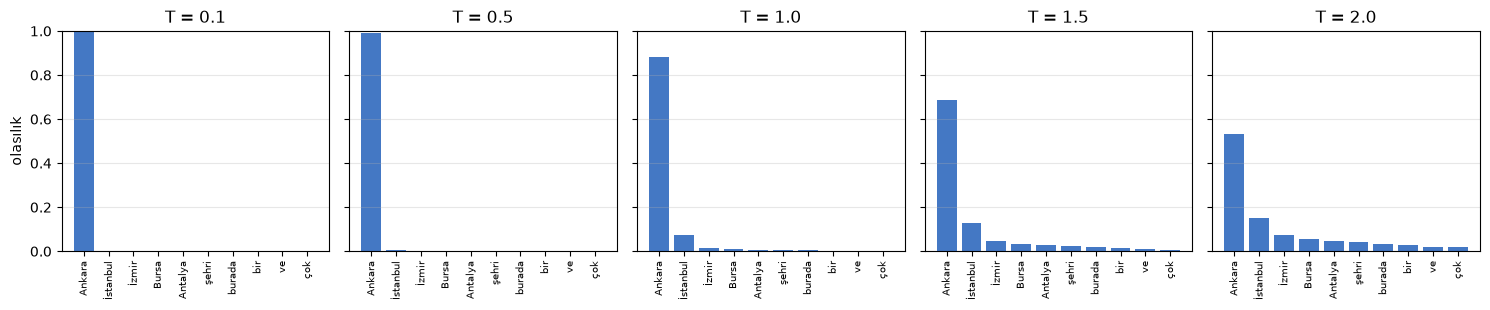

In [4]:
fig, ax = plt.subplots(1, len(sicakliklar), figsize=(15, 3.2), sharey=True)

for j, T in enumerate(sicakliklar):
    p = softmax_sicaklik(logitler, T)
    ax[j].bar(range(len(kelimeler)), p, color="#4478c4")
    ax[j].set_title(f"T = {T}")
    ax[j].set_xticks(range(len(kelimeler)), kelimeler, rotation=90, fontsize=7)
    ax[j].set_ylim(0, 1)
    ax[j].grid(alpha=0.3, axis="y")

ax[0].set_ylabel("olasılık")
plt.tight_layout()
plt.show()

Grafikte sıcaklık arttıkça çubukların düzleştiği net görünüyor.

## 3. Adım - Sıcaklığın çeşitliliğe etkisini ölçüyorum

Yukarıda dağılıma baktım, şimdi **gerçekten örnekleyip** ne olduğuna bakıyorum. Her
sıcaklıkta 2000 kez token seçiyorum ve iki şeyi ölçüyorum:

- **Kaç farklı token çıktı:** çeşitliliğin en basit ölçüsü
- **Entropi:** dağılımın belirsizliğinin matematiksel ölçüsü. 0 ise tam kesinlik,
  büyüdükçe belirsizlik artıyor.

In [5]:
def entropi(p):
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())


ORNEK = 2000
print(f"{'T':>5} {'entropi':>9} {'farklı token':>13} {'Ankara oranı':>14}  en sık 3")
print("-" * 72)

for T in [0.1, 0.5, 1.0, 1.5, 2.0]:
    p = softmax_sicaklik(logitler, T)
    secimler = np.random.choice(len(kelimeler), size=ORNEK, p=p)
    sayim = np.bincount(secimler, minlength=len(kelimeler))
    ilk3 = np.argsort(sayim)[::-1][:3]
    ozet = ", ".join(f"{kelimeler[i]}({sayim[i]})" for i in ilk3)
    print(f"{T:>5} {entropi(p):>9.3f} {(sayim > 0).sum():>13} "
          f"{sayim[0] / ORNEK:>14.3f}  {ozet}")

    T   entropi  farklı token   Ankara oranı  en sık 3
------------------------------------------------------------------------
  0.1     0.000             1          1.000  Ankara(2000), çok(0), ve(0)
  0.5     0.066             3          0.994  Ankara(1987), İstanbul(12), İzmir(1)
  1.0     0.763            10          0.882  Ankara(1765), İstanbul(131), İzmir(41)
  1.5     1.702            10          0.708  Ankara(1416), İstanbul(234), İzmir(87)
  2.0     2.333            10          0.551  Ankara(1102), İstanbul(292), İzmir(155)


Sayılar net: sıcaklık arttıkça entropi büyüyor, farklı token sayısı artıyor ve
Ankara'nın payı düşüyor. T=0.1'de neredeyse hep Ankara geliyor, T=2.0'de model
"İzmir"i bile ciddi oranda seçiyor.

Bu, RAG'de neden düşük sıcaklık kullanıldığının somut sebebi: yüksek sıcaklıkta model
doğru cevaptan sapma ihtimali kazanıyor.

## 4. Adım - Top-K

Top-K, en olası K token dışındaki her şeyi eliyor. Elenen tokenların logiti eksi
sonsuz yapılıyor, böylece softmax sonrası olasılıkları sıfır oluyor.

In [6]:
def top_k_filtre(logitler, k):
    """En olası k token dışındakileri eler."""
    if k <= 0 or k >= len(logitler):
        return logitler.copy()
    yeni = logitler.copy().astype(float)
    esik = np.sort(logitler)[-k]          # k. en büyük değer
    yeni[yeni < esik] = -np.inf
    return yeni


for k in [1, 3, 5, 10]:
    p = softmax(top_k_filtre(logitler, k))
    havuz = [kelimeler[i] for i in range(len(kelimeler)) if p[i] > 0]
    print(f"k={k:<3} havuz ({len(havuz)}): {', '.join(havuz)}")
    print(f"      olasılıklar: {np.round(p[p > 0], 3).tolist()}")
    print()

k=1   havuz (1): Ankara
      olasılıklar: [1.0]

k=3   havuz (3): Ankara, İstanbul, İzmir
      olasılıklar: [0.909, 0.075, 0.017]

k=5   havuz (5): Ankara, İstanbul, İzmir, Bursa, Antalya
      olasılıklar: [0.893, 0.073, 0.016, 0.01, 0.007]

k=10  havuz (10): Ankara, İstanbul, İzmir, Bursa, Antalya, şehri, burada, bir, ve, çok
      olasılıklar: [0.881, 0.072, 0.016, 0.01, 0.007, 0.006, 0.004, 0.002, 0.001, 0.001]



Elenen tokenların olasılığı sıfırlanıyor ve kalanların olasılıkları kendi aralarında
yeniden normalize ediliyor (toplamları yine 1).

## 5. Adım - Top-K'nın zayıf noktası

Raporda Top-K'nın sorununu "K sabit ama dağılım değil" diye yazmıştım. Şimdi bunu
göstermek için **ikinci bir dağılım** kuruyorum: modelin kararsız olduğu bir durum.

"Bugün hava çok" girdisinden sonra pek çok sıfat eşit derecede uygun. Model hiçbirine
kilitlenemiyor.

In [7]:
kelimeler2 = ["güzel", "sıcak", "soğuk", "kapalı", "rüzgarlı",
              "yağmurlu", "nemli", "serin", "bunaltıcı", "berrak"]

# kararsız model: logitler birbirine yakın
logitler2 = np.array([2.2, 2.1, 2.0, 1.95, 1.9, 1.85, 1.8, 1.75, 1.7, 1.6])

p_emin = softmax(logitler)
p_kararsiz = softmax(logitler2)

print("EMİN dağılım      (Türkiye'nin başkenti ...)")
print("  en yüksek olasılık:", f"{p_emin.max():.3f}", " entropi:", f"{entropi(p_emin):.3f}")
print()
print("KARARSIZ dağılım  (Bugün hava çok ...)")
print("  en yüksek olasılık:", f"{p_kararsiz.max():.3f}", " entropi:", f"{entropi(p_kararsiz):.3f}")

EMİN dağılım      (Türkiye'nin başkenti ...)
  en yüksek olasılık: 0.881  entropi: 0.763

KARARSIZ dağılım  (Bugün hava çok ...)
  en yüksek olasılık: 0.135  entropi: 3.300


İki dağılım tamamen farklı karakterde. Şimdi ikisine de **aynı** k=5 uygulayıp ne
olduğuna bakıyorum.

In [8]:
for ad, lg, kelime_listesi in [("EMİN", logitler, kelimeler),
                               ("KARARSIZ", logitler2, kelimeler2)]:
    p = softmax(top_k_filtre(lg, 5))
    havuz = [(kelime_listesi[i], p[i]) for i in range(len(p)) if p[i] > 0]
    print(f"{ad} dağılım, k=5:")
    for kelime, olasilik in havuz:
        print(f"    {kelime:12} {olasilik:.4f}")
    print(f"    -> havuzdaki en düşük olasılık: {min(o for _, o in havuz):.4f}")
    print()

EMİN dağılım, k=5:
    Ankara       0.8931
    İstanbul     0.0733
    İzmir        0.0164
    Bursa        0.0099
    Antalya      0.0073
    -> havuzdaki en düşük olasılık: 0.0073

KARARSIZ dağılım, k=5:
    güzel        0.2357
    sıcak        0.2132
    soğuk        0.1930
    kapalı       0.1835
    rüzgarlı     0.1746
    -> havuzdaki en düşük olasılık: 0.1746



Sorun görünür oldu. Emin dağılımda k=5 demek, model zaten Ankara'dan eminken 4 tane
alakasız şehri yarışa sokmak demek. Kararsız dağılımda ise k=5 gayet makul, çünkü
zaten 5 seçenek de benzer güçte.

Yani **aynı k değeri iki durumda iki farklı şey yapıyor**. Top-P bu yüzden var.

## 6. Adım - Top-P (Nucleus)

Top-P sabit sayı almıyor; olasılıkları büyükten küçüğe toplayıp **kümülatif toplam
P'ye ulaşınca duruyor**. Havuz boyutu böylece dağılıma göre kendiliğinden ayarlanıyor.

In [9]:
def top_p_filtre(logitler, p_esik):
    """Kümülatif olasılık p_esik'e ulaşana kadar token alır, kalanını eler."""
    olasilik = softmax(logitler)
    sira = np.argsort(olasilik)[::-1]        # büyükten küçüğe
    kumulatif = np.cumsum(olasilik[sira])

    # eşiği geçiren ilk tokeni de dahil ediyorum
    kesim = int(np.searchsorted(kumulatif, p_esik)) + 1
    tutulacak = sira[:kesim]

    yeni = np.full_like(logitler, -np.inf, dtype=float)
    yeni[tutulacak] = logitler[tutulacak]
    return yeni


print(f"{'dağılım':12} {'P':>6} {'havuz':>7}  tokenlar")
print("-" * 70)

for ad, lg, kl in [("EMİN", logitler, kelimeler), ("KARARSIZ", logitler2, kelimeler2)]:
    for p_esik in [0.5, 0.9, 0.95]:
        p = softmax(top_p_filtre(lg, p_esik))
        havuz = [kl[i] for i in range(len(p)) if p[i] > 0]
        print(f"{ad:12} {p_esik:>6} {len(havuz):>7}  {', '.join(havuz)}")
    print()

dağılım           P   havuz  tokenlar
----------------------------------------------------------------------
EMİN            0.5       1  Ankara
EMİN            0.9       2  Ankara, İstanbul
EMİN           0.95       2  Ankara, İstanbul

KARARSIZ        0.5       5  güzel, sıcak, soğuk, kapalı, rüzgarlı
KARARSIZ        0.9       9  güzel, sıcak, soğuk, kapalı, rüzgarlı, yağmurlu, nemli, serin, bunaltıcı
KARARSIZ       0.95      10  güzel, sıcak, soğuk, kapalı, rüzgarlı, yağmurlu, nemli, serin, bunaltıcı, berrak



İşte Top-P'nin üstünlüğü burada. Aynı P değeri:

- **Emin** dağılımda küçük bir havuz üretiyor (model zaten kararını vermiş, fazladan
  aday almaya gerek yok)
- **Kararsız** dağılımda geniş bir havuz üretiyor (seçenekler gerçekten yarışıyor)

Top-K'da havuz boyutunu ben sabitliyordum; Top-P'de modelin kendi kararlılığı
belirliyor.

## 7. Adım - Tekrar cezaları

Şimdi modelin daha önce ürettiği tokenları cezalandıran mekanizmalara bakıyorum.
Diyelim ki model şu ana kadar "Ankara" ve "bir" tokenlarını üretmiş, "bir"i de
üç kez.

In [10]:
gecmis = {0: 1, 7: 3}     # {token_indeksi: kaç kez geçtiği} -> Ankara 1, bir 3


def repetition_penalty(logitler, gecmis, ceza=1.2):
    """Geçmişte geçen tokenın logitini böler. Kaç kez geçtiğine bakmaz."""
    yeni = logitler.copy().astype(float)
    for idx in gecmis:
        if yeni[idx] > 0:
            yeni[idx] /= ceza
        else:
            yeni[idx] *= ceza      # negatif logiti bölmek onu büyütürdü
    return yeni


def frequency_penalty(logitler, gecmis, katsayi=0.5):
    """Cezayı geçiş sayısıyla orantılı uygular."""
    yeni = logitler.copy().astype(float)
    for idx, adet in gecmis.items():
        yeni[idx] -= katsayi * adet
    return yeni


def presence_penalty(logitler, gecmis, katsayi=0.5):
    """Bir kez bile geçtiyse sabit ceza."""
    yeni = logitler.copy().astype(float)
    for idx in gecmis:
        yeni[idx] -= katsayi
    return yeni


satirlar = {
    "ceza yok":          logitler,
    "repetition (1.2)":  repetition_penalty(logitler, gecmis, 1.2),
    "frequency (0.5)":   frequency_penalty(logitler, gecmis, 0.5),
    "presence (0.5)":    presence_penalty(logitler, gecmis, 0.5),
}

print("geçmiş: Ankara 1 kez, 'bir' 3 kez geçti")
print()
print(f"{'yöntem':20} {'Ankara olasılık':>16} {'bir olasılık':>14} {'İstanbul':>10}")
print("-" * 64)
for ad, lg in satirlar.items():
    p = softmax(lg)
    print(f"{ad:20} {p[0]:>16.4f} {p[7]:>14.4f} {p[1]:>10.4f}")

geçmiş: Ankara 1 kez, 'bir' 3 kez geçti

yöntem                Ankara olasılık   bir olasılık   İstanbul
----------------------------------------------------------------
ceza yok                       0.8805         0.0022     0.0723
repetition (1.2)               0.6971         0.0047     0.1838
frequency (0.5)                0.8193         0.0007     0.1109
presence (0.5)                 0.8183         0.0020     0.1107


Üç yöntemin farkı tabloda görünüyor:

- **Repetition penalty** kaç kez geçtiğine bakmıyor, sadece geçip geçmediğine bakıyor.
  Burada beklemediğim bir şey oldu: "bir" tokenının olasılığı cezalandırılmasına
  rağmen **arttı** (0.0022 -> 0.0047). Sebebini şöyle anladım: ceza logiti bölerek
  uygulanıyor, Ankara'nın logiti 7.0 olduğu için 1.2'ye bölünce büyük bir mutlak
  düşüş yaşıyor; "bir"in logiti 1.0 olduğu için düşüşü çok küçük. Softmax sonrası
  toplam 1'e normalize edilince Ankara'dan boşalan pay herkese dağılıyor ve "bir"in
  kaybettiğinden fazlasını geri kazanıyor. Yani çarpımsal ceza, küçük logitli
  tokenları cezalandırmakta etkisiz kalabiliyor.
- **Frequency penalty** geçiş sayısıyla orantılı çalışıyor. "bir" üç kez geçtiği için
  ondan çok, Ankara bir kez geçtiği için ondan az düşüyor. Raporda yazdığım "doğal
  olarak sık geçen kelimeleri haksız yere cezalandırmama" avantajı bu.
- **Presence penalty** ikisine de eşit sabit ceza veriyor.

Her üç durumda da cezalanmayan İstanbul'un olasılığı **artıyor**, çünkü toplam 1'e
sabit; birinden düşen pay diğerlerine dağılıyor.

## 8. Adım - Hepsini birleştiriyorum

Gerçek bir üretim hattında bu işlemler sırayla uygulanıyor:

```
logitler -> tekrar cezası -> temperature -> top-k -> top-p -> örnekle
```

Şimdi bu hattı iki farklı ayarla çalıştırıp üretilen token dizilerini karşılaştırıyorum.

In [11]:
def token_sec(logitler, T=1.0, k=0, p_esik=1.0, gecmis=None, freq_katsayi=0.0):
    lg = logitler.copy().astype(float)

    if gecmis and freq_katsayi > 0:          # 1) tekrar cezası
        lg = frequency_penalty(lg, gecmis, freq_katsayi)

    if T <= 0:                               # 2) sıcaklık
        return int(np.argmax(lg))
    lg = lg / T

    if k > 0:                                # 3) top-k
        lg = top_k_filtre(lg, k)

    if p_esik < 1.0:                         # 4) top-p
        lg = top_p_filtre(lg, p_esik)

    return int(np.random.choice(len(lg), p=softmax(lg)))   # 5) örnekle


def uret(adet, **ayar):
    gecmis = {}
    cikti = []
    for _ in range(adet):
        idx = token_sec(logitler, gecmis=gecmis, **ayar)
        cikti.append(kelimeler[idx])
        gecmis[idx] = gecmis.get(idx, 0) + 1
    return cikti


np.random.seed(0)
print("RAG ayarı      (T=0.1, top_p=0.9, ceza yok):")
print("  ", " ".join(uret(12, T=0.1, p_esik=0.9)))
print()

np.random.seed(0)
print("Yaratıcı ayar  (T=1.3, top_p=0.95, freq ceza=0.6):")
print("  ", " ".join(uret(12, T=1.3, p_esik=0.95, freq_katsayi=0.6)))

RAG ayarı      (T=0.1, top_p=0.9, ceza yok):
   Ankara Ankara Ankara Ankara Ankara Ankara Ankara Ankara Ankara Ankara Ankara Ankara

Yaratıcı ayar  (T=1.3, top_p=0.95, freq ceza=0.6):
   Ankara İstanbul Ankara Ankara Ankara İzmir İstanbul şehri burada Ankara Antalya İstanbul


Fark net görünüyor. Düşük sıcaklıklı RAG ayarı 12 adımın hepsinde aynı tokenı
üretiyor; kararlı ama tekdüze. Yaratıcı ayar altı farklı token kullanıyor.

Yaratıcı ayarda hâlâ üst üste gelen tekrarlar var (ortada üç kez arka arkaya
"Ankara"). Yani tekrar cezası tekrarı **azaltıyor ama bitirmiyor**; Ankara'nın
olasılığı o kadar baskın ki 0.6 katsayılı ceza bile onu tamamen devre dışı
bırakamıyor.

RAG için istediğim davranış birincisi. Cevabın her seferinde aynı ve bağlamdaki
ifadeye sadık olmasını istiyorum; çeşitlilik burada bir kusur.

---

## Sonuç

Bu demoda parametrelerin modelin **bilgisini** değil, **seçim biçimini**
değiştirdiğini hesaplayarak gördüm:

- **Temperature** logitleri kendisine bölerek dağılımın keskinliğini ayarlıyor.
  Sıralamayı hiç değiştirmiyor, sadece aradaki mesafeyi açıp kapatıyor. Sıcaklık
  arttıkça entropi ve çeşitlilik ölçülebilir şekilde arttı.
- **Top-K** sabit sayıda aday bırakıyor. Zayıflığını iki farklı dağılımda aynı k
  değerini deneyerek gösterdim: model eminken k=5 gereksiz yere alakasız adayları
  yarışa sokuyor.
- **Top-P** havuz boyutunu dağılımın kendisine göre ayarlıyor; emin dağılımda dar,
  kararsız dağılımda geniş havuz üretti. Top-K'ya tercih edilmesinin sebebi bu.
- **Tekrar cezalarında** repetition ile frequency farkını sayısal olarak gördüm:
  ilki geçip geçmediğine, ikincisi kaç kez geçtiğine bakıyor.
- Bir tokenın olasılığı düşünce diğerlerininki **artıyor**, çünkü toplam hep 1.

Gün 15'te kuracağım RAG sistemi için kararım: sıcaklık sıfıra yakın, tekrar cezası
yok. Amacım yaratıcılık değil, bağlama sadakat.